*Tema*: Data Science\
*Autora*: Luz Enseñat de Carlos

# Análisis Predictivo de Recaida de Diabetes

Vamos a realizar un Análisis Explotario de Datos con Python.

Disponemos de un dataset con la información de adimisiones a hospitales de enfermos de diabetes. El objetivo final del proyecto es, estudiadno el historial clínico de cada paciente, saber cuales de ellos tienen una alta probabilidad de ser readmitidos en los próximos 30 dias por problemas de diabetes.

En el siguiente enlance podemos encontrar una descripción de todas las columnas:
https://fairlearn.org/main/user_guide/datasets/diabetes_hospital_data.html

La *variable objetivo* de nuestro estudio se llama `readmit_30_days` y es una variable binaria, 1 si el paciente fue readmitido en los siguientes 30 días y 0 en caso contrario.

Tendremos en cuenta a la hora de estudiar las variables que las columnas `readmitted` y `readmit_binary` continen esta misma información también pero no podríamos utilizarlas a la hora de predecir la otra porque realmente no se conocen hasta que un paciente es readmitido, que es el objetivo de nuestra predicción.

El resto de variables pueden ser consideradas variables independientes, algunas serán de tipo numérico y muchas de ellas de tipo categórico o binarias.

En este proyecto vamos a hacer un análisis exploratorio de datos tanto Univariante como Bivariante para entender mejor qué tratamientos tenemos que dar a cada variable y cuales pueden ser relevantes a la hora de predecir si un paciente será readmitido en los próximos 30 dias.

## 1.- Carga de Librerías

Lo primero de todo vamos a importar las librerías que vamos a utilizar: Pandas, Matplotlib, Seaborn y Scipy.Stats.

Además, como tenemos muchas columnas por defecto y Pandas las corta a la hora de visualizarlas, cambiamos esta configuración.

In [55]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

# Para que se muestren todas las columnas del DataFrame:

pd.options.display.max_columns = 100

## 2.- Lectura de Datos

Leemos el Dataframe del fichero csv `datos/diabetes.csv` y comprobamos que todo ha ido bien mostrando las 5 primeras filas.

In [56]:
df = pd.read_csv("https://raw.githubusercontent.com/Luz-Ensenat/Diabetes-Readmission-Predictive-Analysis/main/data/diabetes.csv")
df.head(5)

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,Diabetes,1,NaN,NaN,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,Other,9,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,Other,6,NaN,NaN,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,Other,7,NaN,NaN,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,Other,5,NaN,NaN,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


## 3.- Análisis Univariante

### 3.1.-Indentificación y Tratamiento de Nulos

Contamos cuantos valores nulos hay de cada variable y qué % representan:

In [57]:
# Contar valores nulos por columna:

numero_nulos = df.isnull().sum()
porcentaje_nulos = (numero_nulos / len(df)) * 100

print(f'El número de valores nulos por columna es:\n\n{numero_nulos}')
print(f'\n\nEl porcentaje que suponen estos valores nulos por columna es:\n\n{porcentaje_nulos}')

El número de valores nulos por columna es:

race                            0
gender                          0
age                             0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
primary_diagnosis               0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
insulin                         0
change                          0
diabetesMed                     0
medicare                        0
medicaid                        0
had_emergency                   0
had_inpatient_days              0
had_outpatient_days             0
readmitted                      0
readmit_binary                  0
readmit_30_days                 0
dtype: int64


El porcentaje que suponen estos valores nulos por columna es:

race                        

In [58]:
# Como podemos, ver, las variables max_glu_serum y A1Cresult tienen un % de nulos del 95% y 83% respectivamente, muy altos, por lo que consideramos que se pueden eliminar:

df.drop(columns=['max_glu_serum', 'A1Cresult'], inplace=True)

# Verificamos que se eliminaron:

df.head(5)

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,Diabetes,1,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,Other,9,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,Other,6,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,Other,7,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,Other,5,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


In [59]:
# Verificamos que ya no hay valores nulos e imprimimos:

numero_nulos = df.isnull().sum()
print(f'El número de valores nulos por columna es:\n\n{numero_nulos}')

El número de valores nulos por columna es:

race                        0
gender                      0
age                         0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
primary_diagnosis           0
number_diagnoses            0
insulin                     0
change                      0
diabetesMed                 0
medicare                    0
medicaid                    0
had_emergency               0
had_inpatient_days          0
had_outpatient_days         0
readmitted                  0
readmit_binary              0
readmit_30_days             0
dtype: int64


### 3.2.- Análisis y Tratamiento de Variables Categóricas

#### 3.2.1.-Anális de Variables Categóricas

In [60]:
# Empezamos convirtiendo la variable objetivo binaria readmit_30_days a Booleana, para incluirla en las variables categóricas:

df['readmit_30_days'] = df['readmit_30_days'].astype(bool)

# Verificamos e imprimimos:

print(df['readmit_30_days'].dtype)
print(df['readmit_30_days'].value_counts())

bool
readmit_30_days
False    90409
True     11357
Name: count, dtype: int64


In [61]:
#  Como readmitted y readmit_binary contienen información futura respecto a la variable objetivo (readmit_30_days), Las eliminamos:

df.drop(columns=['readmitted', 'readmit_binary'], inplace=True)

# Verificamos que se han eliminado e imprimimos:

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

Columnas actuales del DataFrame:
['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'primary_diagnosis', 'number_diagnoses', 'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid', 'had_emergency', 'had_inpatient_days', 'had_outpatient_days', 'readmit_30_days']


In [62]:
# Ahora filtramos las columnas no numéricas:

non_numeric_vars = df.select_dtypes(exclude=['number']).columns

# Reemplazamos espacios en los valores por guiones bajos en todas las columnas categóricas:

for col in non_numeric_vars:
    df[col] = df[col].astype(str).str.strip().str.replace(' ', '_')

# Mostramos el resultado:

print("Variables no numéricas:")
for col in non_numeric_vars:
    print(f"- {col}")

Variables no numéricas:
- race
- gender
- age
- discharge_disposition_id
- admission_source_id
- medical_specialty
- primary_diagnosis
- insulin
- change
- diabetesMed
- medicare
- medicaid
- had_emergency
- had_inpatient_days
- had_outpatient_days
- readmit_30_days


Lista de variables no numéricas:

Index(['race', 'gender', 'age', 'discharge_disposition_id',
       'admission_source_id', 'medical_specialty', 'primary_diagnosis',
       'insulin', 'change', 'diabetesMed', 'medicare', 'medicaid',
       'had_emergency', 'had_inpatient_days', 'had_outpatient_days',
       'readmit_30_days'],
      dtype='object')


- Distribución de la variable categórica 'race':
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0               Caucasian
1               Caucasian
2         AfricanAmerican
3               Caucasian
4               Caucasian
               ...       
101761    AfricanAmerican
101762    AfricanAmerican
101763          Caucasian
101764          Caucasian
101765          Caucasian
Name: race, Length: 101766, dtype: object>

- F

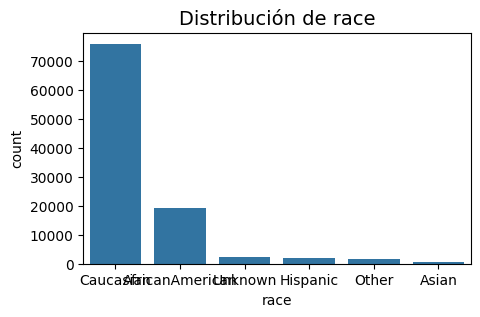



- Distribución de la variable categórica 'gender':
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
101761      Male
101762    Female
101763      Male
101764    Female
101765      Male
Name: gender, Length: 101766, dtype: object>

- Frecuencia Relativa:
gender
Female             0.537586
Male               0.462384
Unknown/Invalid    0.000029
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         Female
1         Female
2         Female
3           Male
4           Male
           ...  
101761      Male
101762    Female
101763      Male
101764    Female
101765      Male
Name: gender, Length: 101766, dtype: object>

- Valores Únicos: 3


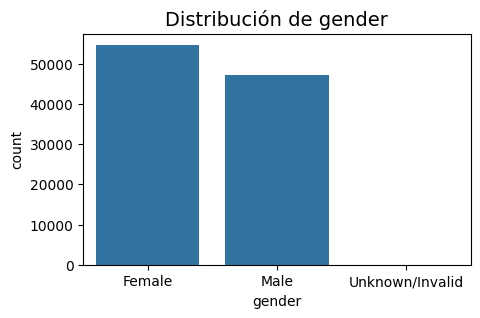



- Distribución de la variable categórica 'age':
age
Over_60_years          68541
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         30_years_or_younger
1         30_years_or_younger
2         30_years_or_younger
3                 30-60_years
4                 30-60_years
                 ...         
101761          Over_60_years
101762          Over_60_years
101763          Over_60_years
101764          Over_60_years
101765          Over_60_years
Name: age, Length: 101766, dtype: object>

- Frecuencia Relativa:
age
Over_60_years          0.673516
30-60_years            0.301830
30_years_or_younger    0.024655
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         30_years_or_younger
1         30_years_or_younger
2         30_years_or_younger
3                 30-60_years
4                 30-60_years
                 ...         
10

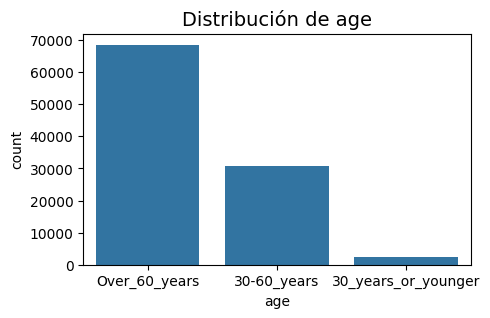



- Distribución de la variable categórica 'discharge_disposition_id':
discharge_disposition_id
Discharged_to_Home    60234
Other                 41532
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0                      Other
1         Discharged_to_Home
2         Discharged_to_Home
3         Discharged_to_Home
4         Discharged_to_Home
                 ...        
101761                 Other
101762                 Other
101763    Discharged_to_Home
101764                 Other
101765    Discharged_to_Home
Name: discharge_disposition_id, Length: 101766, dtype: object>

- Frecuencia Relativa:
discharge_disposition_id
Discharged_to_Home    0.591887
Other                 0.408113
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0                      Other
1         Discharged_to_Home
2         Discharged_to_Home
3         Discharged_to_Home
4         Discharged_to_Home
                 ...        


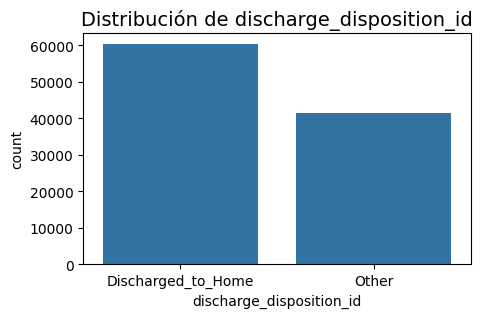



- Distribución de la variable categórica 'admission_source_id':
admission_source_id
Emergency    57494
Referral     30856
Other        13416
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0          Referral
1         Emergency
2         Emergency
3         Emergency
4         Emergency
            ...    
101761    Emergency
101762        Other
101763    Emergency
101764    Emergency
101765    Emergency
Name: admission_source_id, Length: 101766, dtype: object>

- Frecuencia Relativa:
admission_source_id
Emergency    0.564963
Referral     0.303205
Other        0.131832
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0          Referral
1         Emergency
2         Emergency
3         Emergency
4         Emergency
            ...    
101761    Emergency
101762        Other
101763    Emergency
101764    Emergency
101765    Emergency
Name: admission_source_id, Length: 101766, dtype: object>

- Valores

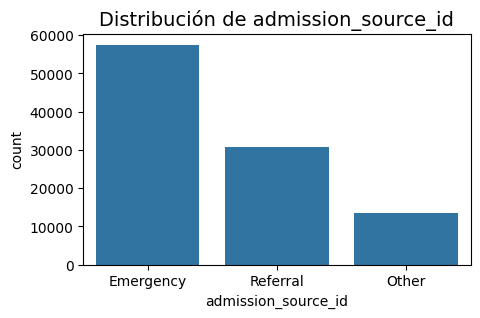



- Distribución de la variable categórica 'medical_specialty':
medical_specialty
Missing                   49949
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0           Other
1         Missing
2         Missing
3         Missing
4         Missing
           ...   
101761    Missing
101762    Missing
101763    Missing
101764      Other
101765    Missing
Name: medical_specialty, Length: 101766, dtype: object>

- Frecuencia Relativa:
medical_specialty
Missing                   0.490822
Other                     0.165330
InternalMedicine          0.143810
Emergency/Trauma          0.074337
Family/GeneralPractice    0.073109
Cardiology                0.052591
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0           Other
1         Missing
2  

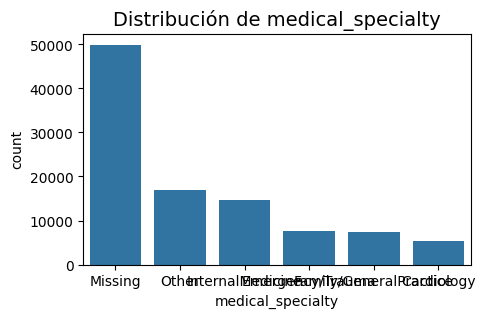



- Distribución de la variable categórica 'primary_diagnosis':
primary_diagnosis
Other                     68512
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         Diabetes
1            Other
2            Other
3            Other
4            Other
            ...   
101761    Diabetes
101762       Other
101763       Other
101764       Other
101765       Other
Name: primary_diagnosis, Length: 101766, dtype: object>

- Frecuencia Relativa:
primary_diagnosis
Other                     0.673231
Respiratory_Issues        0.141727
Diabetes                  0.086050
Genitourinary_Issues      0.050282
Musculoskeletal_Issues    0.048710
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         Diabetes
1            Other
2            Other
3            Other
4            Other


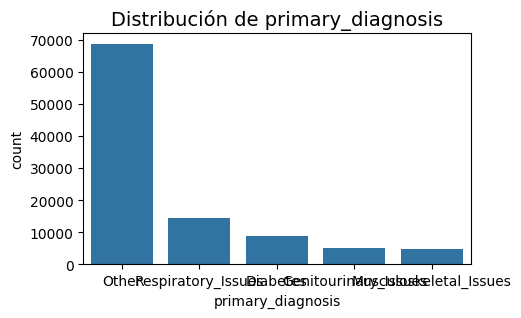



- Distribución de la variable categórica 'insulin':
insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0             No
1             Up
2             No
3             Up
4         Steady
           ...  
101761      Down
101762    Steady
101763      Down
101764        Up
101765        No
Name: insulin, Length: 101766, dtype: object>

- Frecuencia Relativa:
insulin
No        0.465607
Steady    0.303137
Down      0.120060
Up        0.111196
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0             No
1             Up
2             No
3             Up
4         Steady
           ...  
101761      Down
101762    Steady
101763      Down
101764        Up
101765        No
Name: insulin, Length: 101766, dtype: object>

- Valores Únicos: 4


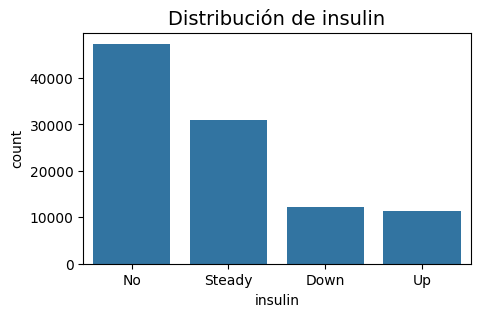



- Distribución de la variable categórica 'change':
change
No    54755
Ch    47011
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         No
1         Ch
2         No
3         Ch
4         Ch
          ..
101761    Ch
101762    No
101763    Ch
101764    Ch
101765    No
Name: change, Length: 101766, dtype: object>

- Frecuencia Relativa:
change
No    0.538048
Ch    0.461952
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         No
1         Ch
2         No
3         Ch
4         Ch
          ..
101761    Ch
101762    No
101763    Ch
101764    Ch
101765    No
Name: change, Length: 101766, dtype: object>

- Valores Únicos: 2


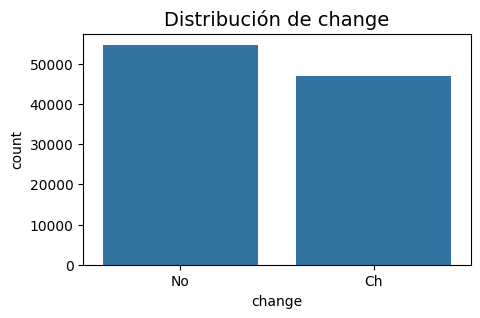



- Distribución de la variable categórica 'diabetesMed':
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0          No
1         Yes
2         Yes
3         Yes
4         Yes
         ... 
101761    Yes
101762    Yes
101763    Yes
101764    Yes
101765     No
Name: diabetesMed, Length: 101766, dtype: object>

- Frecuencia Relativa:
diabetesMed
Yes    0.770031
No     0.229969
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0          No
1         Yes
2         Yes
3         Yes
4         Yes
         ... 
101761    Yes
101762    Yes
101763    Yes
101764    Yes
101765     No
Name: diabetesMed, Length: 101766, dtype: object>

- Valores Únicos: 2


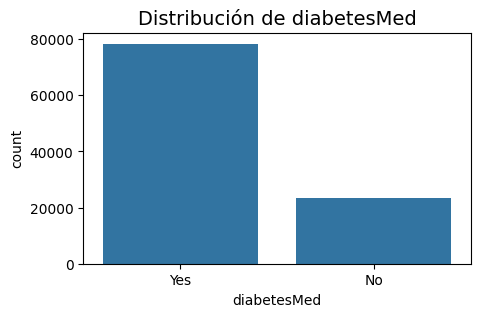



- Distribución de la variable categórica 'medicare':
medicare
False    69327
True     32439
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761     True
101762     True
101763     True
101764     True
101765    False
Name: medicare, Length: 101766, dtype: object>

- Frecuencia Relativa:
medicare
False    0.681239
True     0.318761
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761     True
101762     True
101763     True
101764     True
101765    False
Name: medicare, Length: 101766, dtype: object>

- Valores Únicos: 2


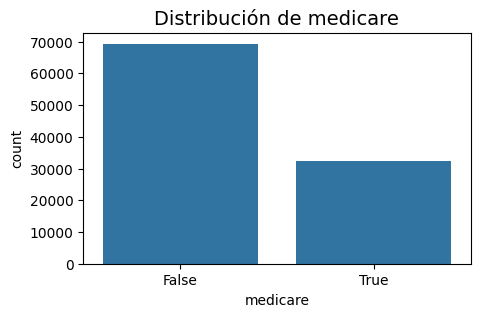



- Distribución de la variable categórica 'medicaid':
medicaid
False    98234
True      3532
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: medicaid, Length: 101766, dtype: object>

- Frecuencia Relativa:
medicaid
False    0.965293
True     0.034707
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: medicaid, Length: 101766, dtype: object>

- Valores Únicos: 2


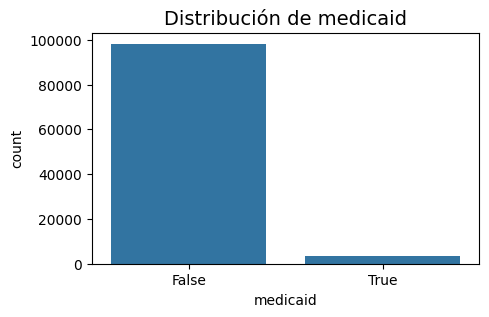



- Distribución de la variable categórica 'had_emergency':
had_emergency
False    90383
True     11383
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: had_emergency, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_emergency
False    0.888145
True     0.111855
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: had_emergency, Length: 101766, dtype: object>

- Valores Únicos: 2


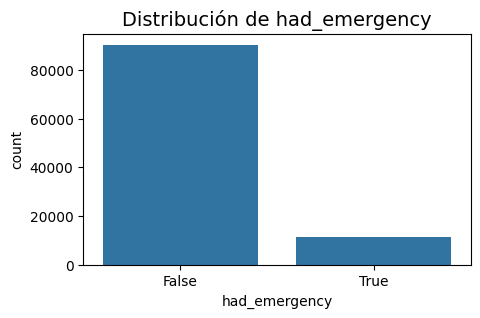



- Distribución de la variable categórica 'had_inpatient_days':
had_inpatient_days
False    67630
True     34136
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762     True
101763    False
101764     True
101765    False
Name: had_inpatient_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_inpatient_days
False    0.664564
True     0.335436
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762     True
101763    False
101764     True
101765    False
Name: had_inpatient_days, Length: 101766, dtype: object>

- Valores Únicos: 2


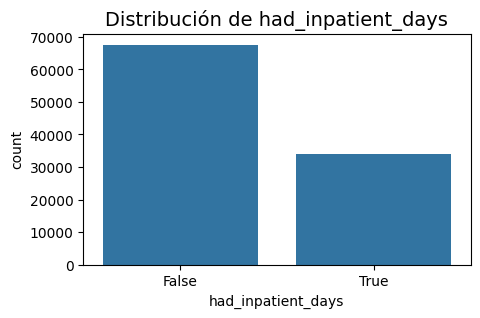



- Distribución de la variable categórica 'had_outpatient_days':
had_outpatient_days
False    85027
True     16739
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762    False
101763     True
101764    False
101765    False
Name: had_outpatient_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
had_outpatient_days
False    0.835515
True     0.164485
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2          True
3         False
4         False
          ...  
101761    False
101762    False
101763     True
101764    False
101765    False
Name: had_outpatient_days, Length: 101766, dtype: object>

- Valores Únicos: 2


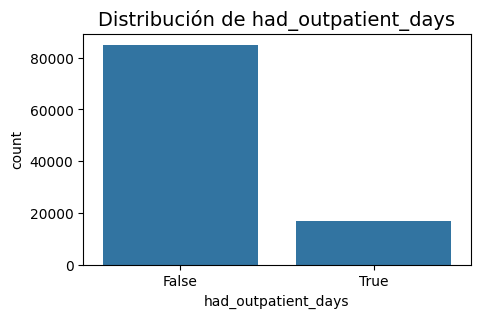



- Distribución de la variable categórica 'readmit_30_days':
readmit_30_days
False    90409
True     11357
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
<bound method IndexOpsMixin.value_counts of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: readmit_30_days, Length: 101766, dtype: object>

- Frecuencia Relativa:
readmit_30_days
False    0.888401
True     0.111599
Name: proportion, dtype: float64

- Moda:
<bound method Series.mode of 0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: readmit_30_days, Length: 101766, dtype: object>

- Valores Únicos: 2


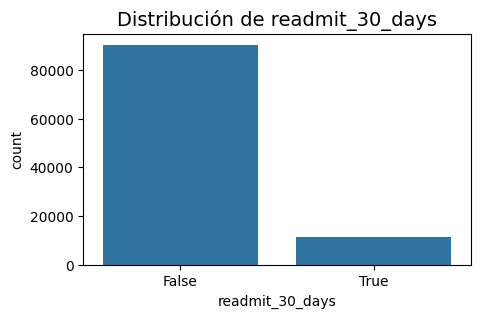

In [63]:
# Hacemos una lista con las variables no numéricas:

non_numeric_vars = df.select_dtypes(exclude=['number']).columns

# Mostramos la lista:

print("Lista de variables no numéricas:\n")
print(non_numeric_vars)

# Recorremos las variables categóricas y mostramos su distribución, tipo, frecuencia absoluta y relativa, la moda , Valores Únicos y Gráfico de Barras ordenado por Frecuencia Relativa:

for var in non_numeric_vars:
    print(f"\n\n- Distribución de la variable categórica '{var}':")
    print(df[var].value_counts())
    print(f"\n- Tipo: {df[var].dtype}")
    print(f"\n- Frecuencia Absoluta:\n{df[var].value_counts}")
    print(f"\n- Frecuencia Relativa:\n{df[var].value_counts(normalize = True)}")
    print(f"\n- Moda:\n{df[var].mode}")
    print(f"\n- Valores Únicos: {df[var].nunique()}")
    plt.figure (figsize = (5, 3))
    sns.countplot(x=var, data=df, order=df[var].value_counts().index)
    plt.title(f'Distribución de {var}', fontsize = 14)
    plt.show()

#### 3.2.3.- Eliminación de Variables Categóricas con prácticamente un sólo valor

In [64]:
# Como hemos observado que hay algunas variable que prácticamente toman un sólo valor (95% de los valores pertenecen a una única categoría) y puesto que no aportan gran información
# para nuestro caso, vamos a eliminarlas:

threshold = 0.95

# Identificamos variables a eliminar:

vars_to_drop = []

for col in non_numeric_vars:
    unique_vals = df[col].nunique(dropna=False)
    max_freq = df[col].value_counts(normalize=True, dropna=False).max()

    if unique_vals == 1:
        print(f"Variable '{col}' tiene un solo valor único. Se eliminará.")
        vars_to_drop.append(col)
    elif max_freq >= threshold:
        print(f"Variable '{col}' es casi constante ({max_freq*100:.2f}% del mismo valor). Se eliminará.")
        vars_to_drop.append(col)

# Creamos un nuevo dataset sin esas columnas:

df_clean = df.drop(columns=vars_to_drop)

# Imprimimos resumen:

print(f"\nVariables eliminadas: {vars_to_drop}")
print(f"Nuevo dataset creado con {df_clean.shape[1]} columnas y {df_clean.shape[0]} filas.")

Variable 'medicaid' es casi constante (96.53% del mismo valor). Se eliminará.

Variables eliminadas: ['medicaid']
Nuevo dataset creado con 20 columnas y 101766 filas.


#### 3.2.4- Eliminación de filas poco frecuentes o Outliers

In [65]:
# Hemos visto en los gráficos que en algunas variables hay valores muy poco frecuentes. Definimos un umbral del 0,5% para la eliminación de filas poco frecuentes, que no aportan gran información a nuestro caso:

threshold = 0.005  # 0.5%

# Trabajamos sobre una copia del dataframe limpio:

df_filtered = df_clean.copy()

# Filtramos filas que tienen valores poco frecuentes en variables categóricas:

for col in df_filtered.select_dtypes(exclude=['number']).columns:
    # Calculamos frecuencia relativa
    freq = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_categories = freq[freq < threshold].index.tolist()

    if rare_categories:
        print(f" En '{col}', se eliminarán filas con valores raros: {rare_categories}")
        df_filtered = df_filtered[~df_filtered[col].isin(rare_categories)]

# Imprimimos resumen:

print(f"\nDataset después de eliminar filas con valores poco frecuentes:")
print(f"Filas restantes: {df_filtered.shape[0]}")
print(f"Columnas: {df_filtered.shape[1]}")

 En 'gender', se eliminarán filas con valores raros: ['Unknown/Invalid']

Dataset después de eliminar filas con valores poco frecuentes:
Filas restantes: 101763
Columnas: 20


#### 3.2.5- Agrupación de valores poco frecuentes de las variables categóricas

In [66]:
# Hemos visto en los gráficos que en algunas variables hay valores poco frecuentes. Definimos un umbral del 2% para la agrupación de filas poco frecuentes, para simplificar sin gran pérdida de información:

threshold = 0.02

# Hacemos una copia del DataFrame para no modificar el original:

df_grouped = df_filtered.copy()

# Recorremos las columnas categóricas:

for col in df_grouped.select_dtypes(exclude=['number']).columns:

    # Calculamos la frecuencia relativa:

    freq = df_grouped[col].value_counts(normalize=True)

    # Identificamos categorías raras (menos frecuentes que el umbral):

    rare_categories = freq[freq < threshold].index

    # Reemplazamos esas categorías por 'Others':

    df_grouped[col] = df_grouped[col].apply(lambda x: 'Others' if x in rare_categories else x)

    # Imprimimos resumen:

    if len(rare_categories) > 0:
        print(f"Columna '{col}': {len(rare_categories)} categorías agrupadas como 'Others'.")

# Imprimimos forma final del dataset:

print(f"\nDataset final con categorías poco frecuentes agrupadas.")
print(f"Filas: {df_grouped.shape[0]}, Columnas: {df_grouped.shape[1]}")

# Imprimimos las primeras filas de df_grouped:

df_grouped.head(5)

Columna 'race': 2 categorías agrupadas como 'Others'.

Dataset final con categorías poco frecuentes agrupadas.
Filas: 101763, Columnas: 20


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,insulin,change,diabetesMed,medicare,had_emergency,had_inpatient_days,had_outpatient_days,readmit_30_days
0,Caucasian,Female,30_years_or_younger,Other,Referral,1,Other,41,0,1,Diabetes,1,No,No,No,False,False,False,False,False
1,Caucasian,Female,30_years_or_younger,Discharged_to_Home,Emergency,3,Missing,59,0,18,Other,9,Up,Ch,Yes,False,False,False,False,False
2,AfricanAmerican,Female,30_years_or_younger,Discharged_to_Home,Emergency,2,Missing,11,5,13,Other,6,No,No,Yes,False,False,True,True,False
3,Caucasian,Male,30-60_years,Discharged_to_Home,Emergency,2,Missing,44,1,16,Other,7,Up,Ch,Yes,False,False,False,False,False
4,Caucasian,Male,30-60_years,Discharged_to_Home,Emergency,1,Missing,51,0,8,Other,5,Steady,Ch,Yes,False,False,False,False,False


#### 3.2.6- Conversión a Variables Booleanas

In [67]:
# Identificamos las variables que sólo toman 2 valores (variables categóricas binarias):

binary_df_grouped = [col for col in df_grouped if df[col].nunique(dropna=False) == 2]

# Mostramos el resultado:

print('Variables no numéricas con solo 2 valores únicos:')
for col in binary_df_grouped:
    print(f"- {col}: {df[col].unique()}")

Variables no numéricas con solo 2 valores únicos:
- discharge_disposition_id: ['Other' 'Discharged_to_Home']
- change: ['No' 'Ch']
- diabetesMed: ['No' 'Yes']
- medicare: ['False' 'True']
- had_emergency: ['False' 'True']
- had_inpatient_days: ['False' 'True']
- had_outpatient_days: ['False' 'True']
- readmit_30_days: ['False' 'True']


In [68]:
# Convertimos cada variable binaria a booleana:

for col in binary_df_grouped:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) == 2:
        true_val = unique_vals[0]
        false_val = unique_vals[1]
        print(f"Convirtiendo '{col}': '{true_val}' -> True, '{false_val}' -> False")
        df[col] = df[col].map({true_val: True, false_val: False})
    else:
        print(f"Variable '{col}' tiene valores especiales que se omiten.")

# Comprobamos el cambio:

print("\nVariables convertidas a booleanas:")
print(df[binary_df_grouped].head())

Convirtiendo 'discharge_disposition_id': 'Other' -> True, 'Discharged_to_Home' -> False
Convirtiendo 'change': 'No' -> True, 'Ch' -> False
Convirtiendo 'diabetesMed': 'No' -> True, 'Yes' -> False
Convirtiendo 'medicare': 'False' -> True, 'True' -> False
Convirtiendo 'had_emergency': 'False' -> True, 'True' -> False
Convirtiendo 'had_inpatient_days': 'False' -> True, 'True' -> False
Convirtiendo 'had_outpatient_days': 'False' -> True, 'True' -> False
Convirtiendo 'readmit_30_days': 'False' -> True, 'True' -> False

Variables convertidas a booleanas:
   discharge_disposition_id  change  diabetesMed  medicare  had_emergency  \
0                      True    True         True      True           True   
1                     False   False        False      True           True   
2                     False    True        False      True           True   
3                     False   False        False      True           True   
4                     False   False        False      True  

#### 3.2.7.- Análisis de las Variables Categóricas una vez "limpio" el DataFrame



Distribución de la variable categórica 'race':
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2271
Others              2146
Hispanic            2037
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2271
Others              2146
Hispanic            2037
Name: count, dtype: int64

- Frecuencia Relativa:
race
Caucasian          0.747806
AfricanAmerican    0.188772
Unknown            0.022317
Others             0.021088
Hispanic           0.020017
Name: proportion, dtype: float64

- Moda: Caucasian

- Valores Únicos: 5


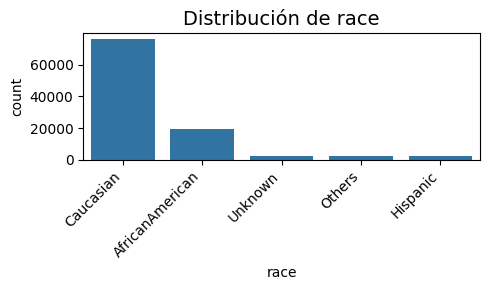



Distribución de la variable categórica 'gender':
gender
Female    54708
Male      47055
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
gender
Female    54708
Male      47055
Name: count, dtype: int64

- Frecuencia Relativa:
gender
Female    0.537602
Male      0.462398
Name: proportion, dtype: float64

- Moda: Female

- Valores Únicos: 2


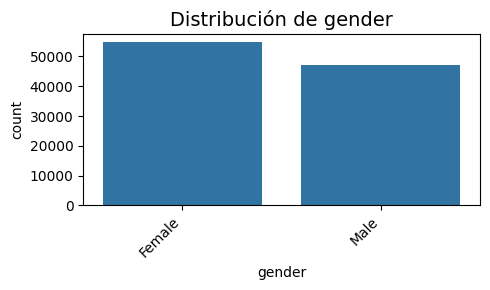



Distribución de la variable categórica 'age':
age
Over_60_years          68538
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
age
Over_60_years          68538
30-60_years            30716
30_years_or_younger     2509
Name: count, dtype: int64

- Frecuencia Relativa:
age
Over_60_years          0.673506
30-60_years            0.301839
30_years_or_younger    0.024655
Name: proportion, dtype: float64

- Moda: Over_60_years

- Valores Únicos: 3


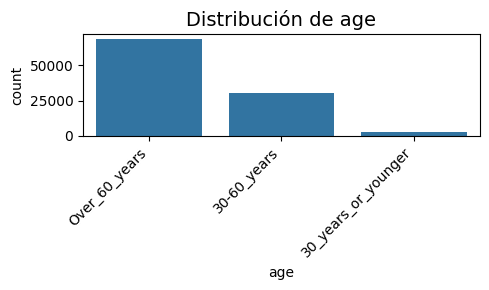



Distribución de la variable categórica 'discharge_disposition_id':
discharge_disposition_id
Discharged_to_Home    60232
Other                 41531
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
discharge_disposition_id
Discharged_to_Home    60232
Other                 41531
Name: count, dtype: int64

- Frecuencia Relativa:
discharge_disposition_id
Discharged_to_Home    0.591885
Other                 0.408115
Name: proportion, dtype: float64

- Moda: Discharged_to_Home

- Valores Únicos: 2


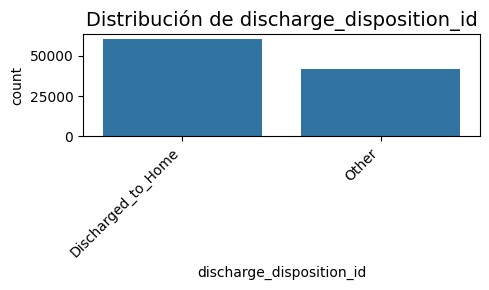



Distribución de la variable categórica 'admission_source_id':
admission_source_id
Emergency    57492
Referral     30855
Other        13416
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
admission_source_id
Emergency    57492
Referral     30855
Other        13416
Name: count, dtype: int64

- Frecuencia Relativa:
admission_source_id
Emergency    0.564960
Referral     0.303205
Other        0.131836
Name: proportion, dtype: float64

- Moda: Emergency

- Valores Únicos: 3


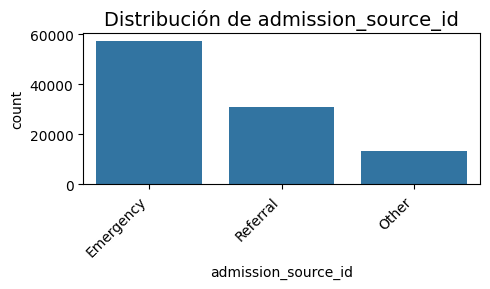



Distribución de la variable categórica 'medical_specialty':
medical_specialty
Missing                   49947
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5351
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
medical_specialty
Missing                   49947
Other                     16825
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5351
Name: count, dtype: int64

- Frecuencia Relativa:
medical_specialty
Missing                   0.490817
Other                     0.165335
InternalMedicine          0.143815
Emergency/Trauma          0.074339
Family/GeneralPractice    0.073111
Cardiology                0.052583
Name: proportion, dtype: float64

- Moda: Missing

- Valores Únicos: 6


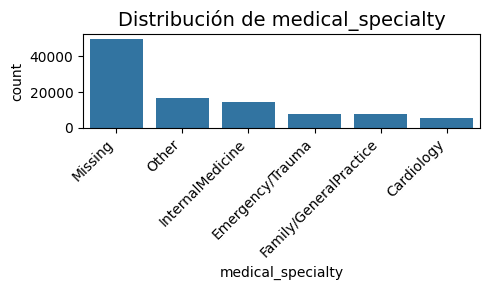



Distribución de la variable categórica 'primary_diagnosis':
primary_diagnosis
Other                     68509
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
primary_diagnosis
Other                     68509
Respiratory_Issues        14423
Diabetes                   8757
Genitourinary_Issues       5117
Musculoskeletal_Issues     4957
Name: count, dtype: int64

- Frecuencia Relativa:
primary_diagnosis
Other                     0.673221
Respiratory_Issues        0.141731
Diabetes                  0.086053
Genitourinary_Issues      0.050284
Musculoskeletal_Issues    0.048711
Name: proportion, dtype: float64

- Moda: Other

- Valores Únicos: 5


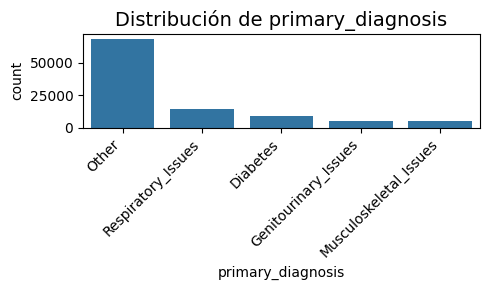



Distribución de la variable categórica 'insulin':
insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
insulin
No        47380
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

- Frecuencia Relativa:
insulin
No        0.465592
Steady    0.303146
Down      0.120063
Up        0.111200
Name: proportion, dtype: float64

- Moda: No

- Valores Únicos: 4


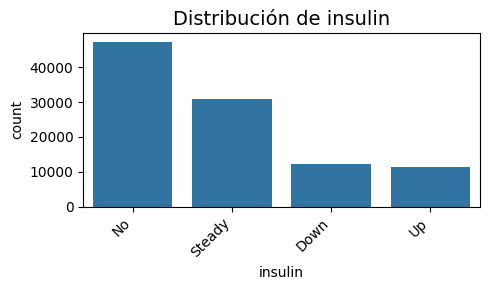



Distribución de la variable categórica 'change':
change
No    54754
Ch    47009
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
change
No    54754
Ch    47009
Name: count, dtype: int64

- Frecuencia Relativa:
change
No    0.538054
Ch    0.461946
Name: proportion, dtype: float64

- Moda: No

- Valores Únicos: 2


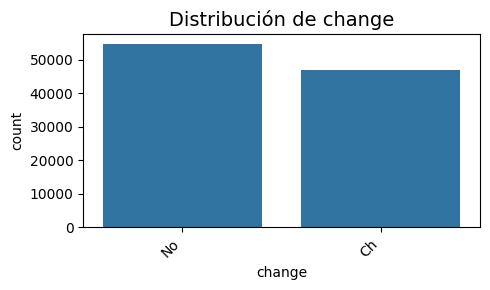



Distribución de la variable categórica 'diabetesMed':
diabetesMed
Yes    78361
No     23402
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
diabetesMed
Yes    78361
No     23402
Name: count, dtype: int64

- Frecuencia Relativa:
diabetesMed
Yes    0.770034
No     0.229966
Name: proportion, dtype: float64

- Moda: Yes

- Valores Únicos: 2


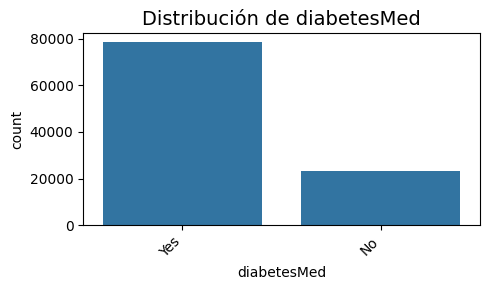



Distribución de la variable categórica 'medicare':
medicare
False    69324
True     32439
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
medicare
False    69324
True     32439
Name: count, dtype: int64

- Frecuencia Relativa:
medicare
False    0.68123
True     0.31877
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


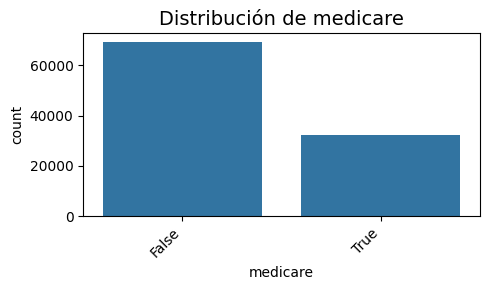



Distribución de la variable categórica 'had_emergency':
had_emergency
False    90380
True     11383
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
had_emergency
False    90380
True     11383
Name: count, dtype: int64

- Frecuencia Relativa:
had_emergency
False    0.888142
True     0.111858
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


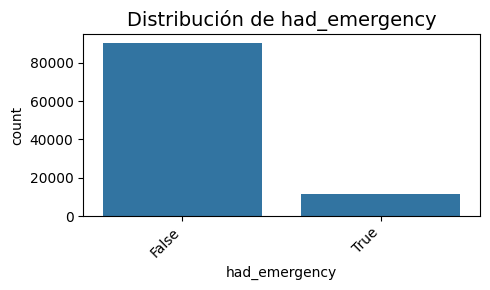



Distribución de la variable categórica 'had_inpatient_days':
had_inpatient_days
False    67627
True     34136
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
had_inpatient_days
False    67627
True     34136
Name: count, dtype: int64

- Frecuencia Relativa:
had_inpatient_days
False    0.664554
True     0.335446
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


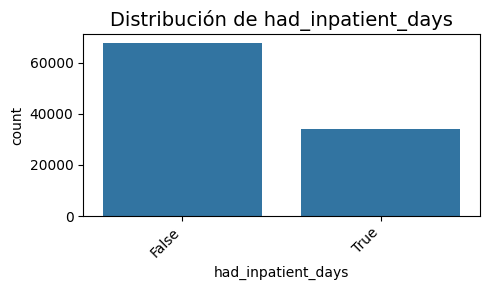



Distribución de la variable categórica 'had_outpatient_days':
had_outpatient_days
False    85024
True     16739
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
had_outpatient_days
False    85024
True     16739
Name: count, dtype: int64

- Frecuencia Relativa:
had_outpatient_days
False    0.83551
True     0.16449
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


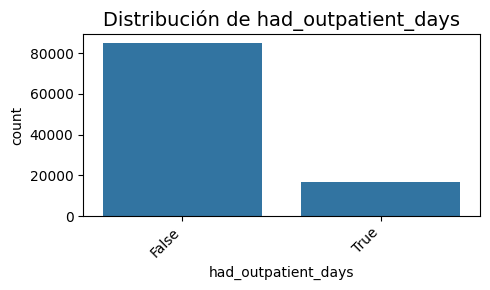



Distribución de la variable categórica 'readmit_30_days':
readmit_30_days
False    90406
True     11357
Name: count, dtype: int64

- Tipo: object

- Frecuencia Absoluta:
readmit_30_days
False    90406
True     11357
Name: count, dtype: int64

- Frecuencia Relativa:
readmit_30_days
False    0.888398
True     0.111602
Name: proportion, dtype: float64

- Moda: False

- Valores Únicos: 2


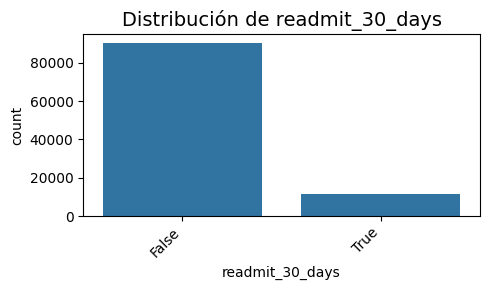

In [69]:
# Recorremos de nuevo las variables categóricas después de nuestras actuaciones y mostramos su distribución, tipo, frecuencia absoluta y relativa, la moda , Valores Únicos y Gráfico
# de Barras ordenado por Frecuencia Relativa:

cat_cols = df_grouped.select_dtypes(exclude='number').columns

for var in cat_cols:
    print(f"\n\nDistribución de la variable categórica '{var}':")

    # Estadísticas de frecuencia:

    print(df_grouped[var].value_counts())
    print(f"\n- Tipo: {df_grouped[var].dtype}")
    print(f"\n- Frecuencia Absoluta:\n{df_grouped[var].value_counts()}")
    print(f"\n- Frecuencia Relativa:\n{df_grouped[var].value_counts(normalize=True)}")
    print(f"\n- Moda: {df_grouped[var].mode()[0]}")
    print(f"\n- Valores Únicos: {df_grouped[var].nunique()}")

    # Gráficos de barras:

    plt.figure(figsize=(5, 3))
    sns.countplot(x=var, data=df_grouped, order=df_grouped[var].value_counts().index)
    plt.title(f'Distribución de {var}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Observamos en los gráficos y datos que ya sólo nos hemos quedado con las variables que pueden aportarnos información para el caso y hemos eliminado o agrupado los valores menos significativos. La conversión de columnas categóricas a Booleanas nos facilitará el análisis Multivariante.

### 3.3.- Análisis y Tratamiento de Variables Numéricas

Estudia ahora cada una de las variables numéricas, observa las distribuciones y discute la presencia de outliers y la forma de tratarlos en cada caso.

Deberías como mímimo mostrar los boxplots y los histogramas de cada una de las variables para conocer su distribución.

#### 3.3.1.-Anális de Variables Numéricas

In [70]:
# Lista de variables numéricas:

numeric_var = df_grouped.select_dtypes(include='number').columns

print("Variables numéricas a analizar:")
print(numeric_var)

Variables numéricas a analizar:
Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_diagnoses'],
      dtype='object')



Análisis de la variable numérica: 'time_in_hospital'
--------------------------------------------------
Media: 4.3960
Mediana: 4.0000
Varianza: 8.9108
Desviación Típica: 2.9851
IQR (Rango Intercuartílico): 4.0000


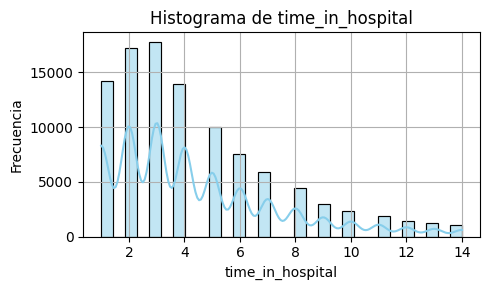

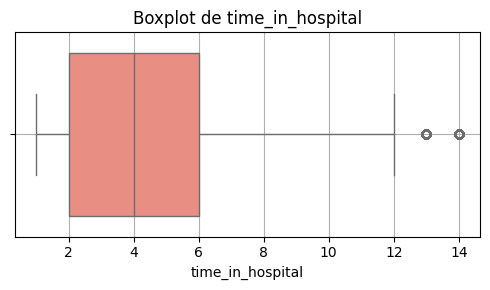


Análisis de la variable numérica: 'num_lab_procedures'
--------------------------------------------------
Media: 43.0959
Mediana: 44.0000
Varianza: 387.0749
Desviación Típica: 19.6742
IQR (Rango Intercuartílico): 26.0000


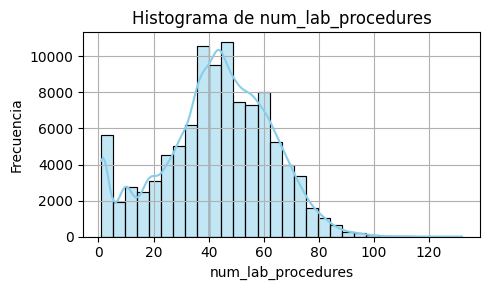

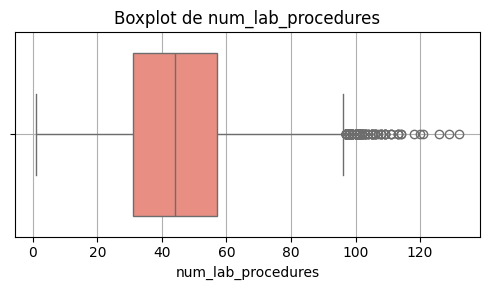


Análisis de la variable numérica: 'num_procedures'
--------------------------------------------------
Media: 1.3397
Mediana: 1.0000
Varianza: 2.9097
Desviación Típica: 1.7058
IQR (Rango Intercuartílico): 2.0000


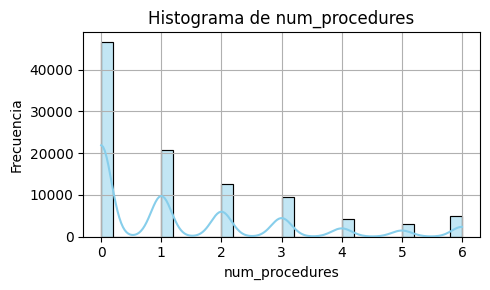

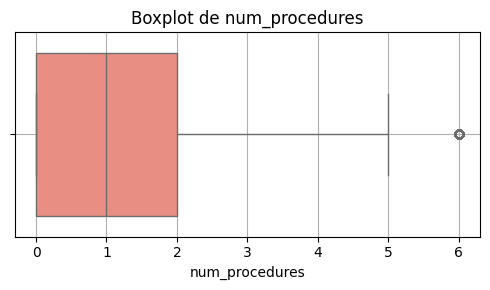


Análisis de la variable numérica: 'num_medications'
--------------------------------------------------
Media: 16.0218
Mediana: 15.0000
Varianza: 66.0577
Desviación Típica: 8.1276
IQR (Rango Intercuartílico): 10.0000


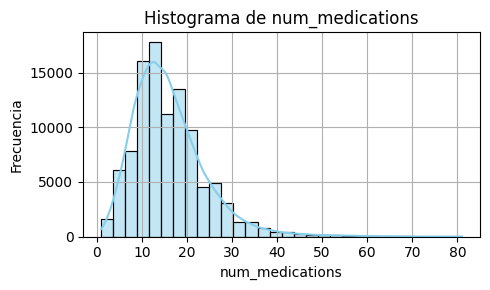

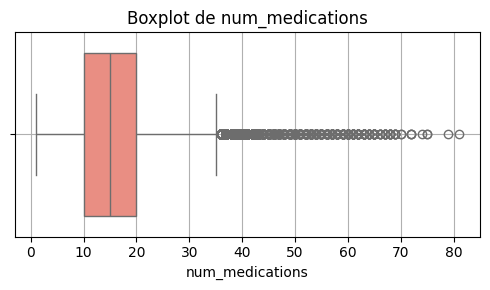


Análisis de la variable numérica: 'number_diagnoses'
--------------------------------------------------
Media: 7.4226
Mediana: 8.0000
Varianza: 3.7387
Desviación Típica: 1.9336
IQR (Rango Intercuartílico): 3.0000


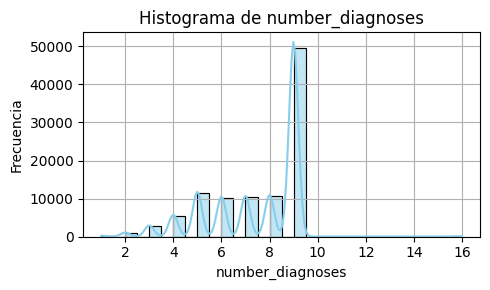

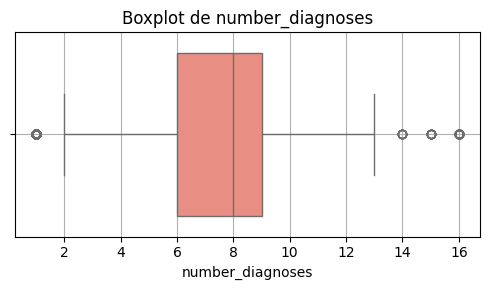

In [71]:
# Recorremos cada variable numérica:

for col in numeric_var:
    print(f"\nAnálisis de la variable numérica: '{col}'")
    print("-" * 50)

    # Métodos Numéricos:

    mean = df_grouped[col].mean()
    median = df_grouped[col].median()
    variance = df_grouped[col].var()
    std_dev = df_grouped[col].std()
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Media: {mean:.4f}")
    print(f"Mediana: {median:.4f}")
    print(f"Varianza: {variance:.4f}")
    print(f"Desviación Típica: {std_dev:.4f}")
    print(f"IQR (Rango Intercuartílico): {IQR:.4f}")

    # Métodos Gráficos: Histograma:

    plt.figure(figsize=(5, 3))
    sns.histplot(df_grouped[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Métodos Gráficos: Boxplot:

    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df_grouped[col], color='salmon')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Observando los Boxplots podemos ver que hay muchos Outliers.

#### 3.3.2.-Detección de Outliers mediante el Test de Tukey

In [72]:
# Puesto que no conocemos bien el dominio de las variables ni los umbrales a apliacar, utilizaremos este método para detactar Outliers.

# Calculamos los límites inferior y superior para los Outliers:

for col in numeric_var:

    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    # Calculamos los Outliers:

    outliers = df_grouped[(df_grouped[col] < inferior) | (df_grouped[col] > superior)]

    # Imprimimos cuántos outliers hay en cada variable:

    num_outliers = outliers.shape[0]
    print(f"- {col}: {num_outliers} outliers")

- time_in_hospital: 2252 outliers
- num_lab_procedures: 143 outliers
- num_procedures: 4954 outliers
- num_medications: 2557 outliers
- number_diagnoses: 281 outliers


### 3.3.4.-Tratamiento de Outliers

In [73]:
# Puesto que se trata de muchos Outliers y desconocemos la importancia de la información por ellos suministrada, los imputaremos por el valor del tercer cuartil más 1.5 veces
# el rango intercuartílico o por el valor del primer cuartil menos 1.5 veces el rango intercuartílico:

for col in numeric_var:
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    # Reemplazamos outliers por los límites e imprimimos:

    df_grouped[col] = df_grouped[col].apply(lambda x: inferior if x < inferior else (superior if x > superior else x))
    print(f"{col}: Outliers imputados con límites Tukey.")

time_in_hospital: Outliers imputados con límites Tukey.
num_lab_procedures: Outliers imputados con límites Tukey.
num_procedures: Outliers imputados con límites Tukey.
num_medications: Outliers imputados con límites Tukey.
number_diagnoses: Outliers imputados con límites Tukey.



Análisis de la variable numérica: 'time_in_hospital'
--------------------------------------------------
Media: 4.3636
Mediana: 4.0000
Varianza: 8.3646
Desviación Típica: 2.8922
IQR (Rango Intercuartílico): 4.0000


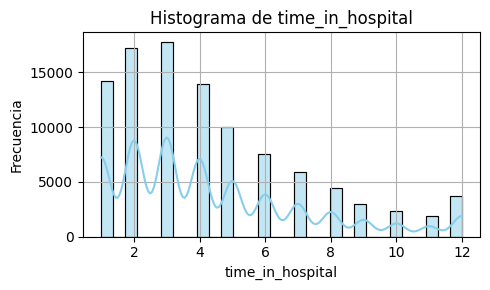

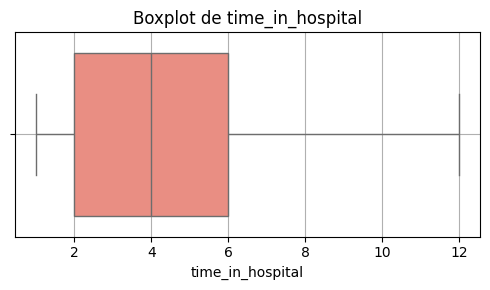


Análisis de la variable numérica: 'num_lab_procedures'
--------------------------------------------------
Media: 43.0875
Mediana: 44.0000
Varianza: 386.0742
Desviación Típica: 19.6488
IQR (Rango Intercuartílico): 26.0000


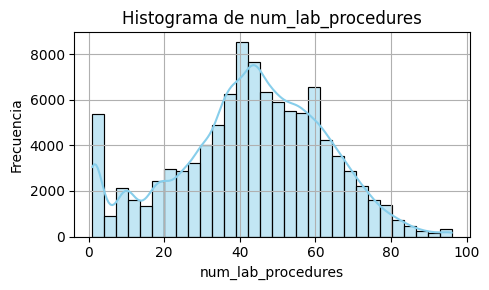

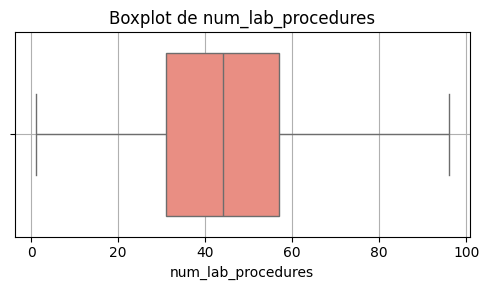


Análisis de la variable numérica: 'num_procedures'
--------------------------------------------------
Media: 1.2910
Mediana: 1.0000
Varianza: 2.5023
Desviación Típica: 1.5819
IQR (Rango Intercuartílico): 2.0000


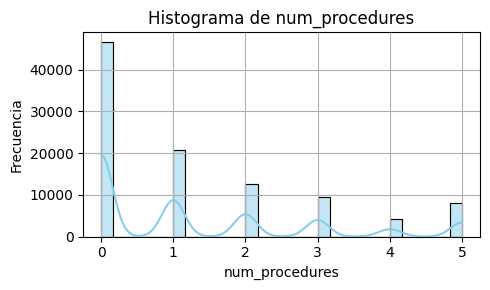

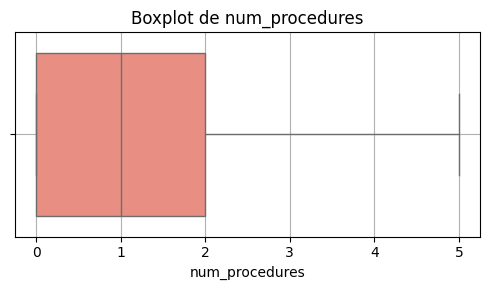


Análisis de la variable numérica: 'num_medications'
--------------------------------------------------
Media: 15.8085
Mediana: 15.0000
Varianza: 54.7104
Desviación Típica: 7.3966
IQR (Rango Intercuartílico): 10.0000


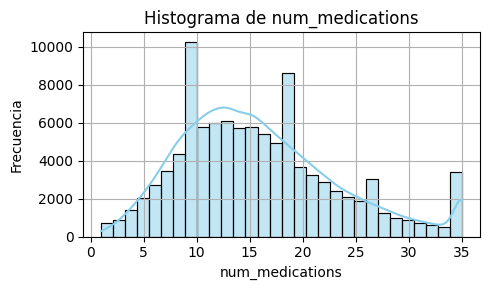

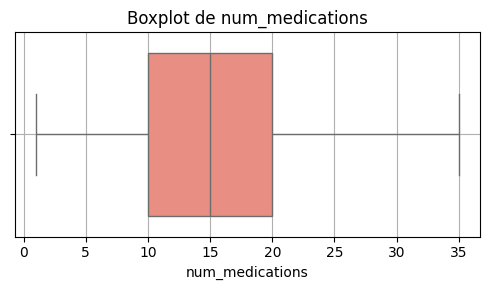


Análisis de la variable numérica: 'number_diagnoses'
--------------------------------------------------
Media: 7.4224
Mediana: 8.0000
Varianza: 3.7068
Desviación Típica: 1.9253
IQR (Rango Intercuartílico): 3.0000


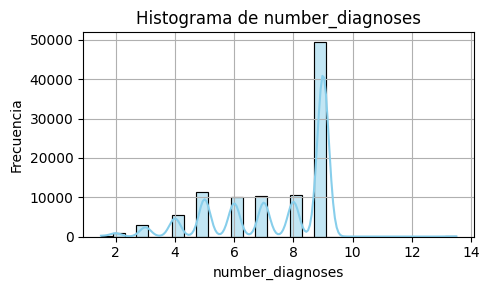

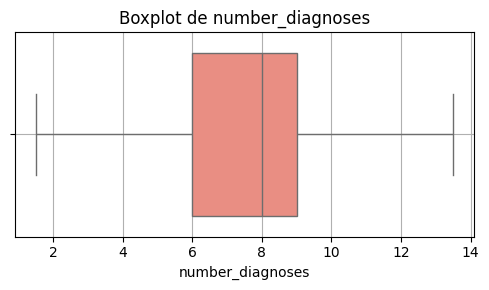

In [74]:
# Recorremos otra vez cada variable numérica después de la imputación de Outliers para ver cómo ha resultado:

for col in numeric_var:
    print(f"\nAnálisis de la variable numérica: '{col}'")
    print("-" * 50)

    # Métodos Numéricos:

    mean = df_grouped[col].mean()
    median = df_grouped[col].median()
    variance = df_grouped[col].var()
    std_dev = df_grouped[col].std()
    Q1 = df_grouped[col].quantile(0.25)
    Q3 = df_grouped[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"Media: {mean:.4f}")
    print(f"Mediana: {median:.4f}")
    print(f"Varianza: {variance:.4f}")
    print(f"Desviación Típica: {std_dev:.4f}")
    print(f"IQR (Rango Intercuartílico): {IQR:.4f}")

    # Métodos Gráficos: Histograma:

    plt.figure(figsize=(5, 3))
    sns.histplot(df_grouped[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Métodos Gráficos: Boxplot:

    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df_grouped[col], color='salmon')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 4.- Análisis Multivariante

Una vez completado el análisis univariante es hora de de hacer el bivariante. Veremos cómo se comportan las variables entre ellas. Nos importa especialmente la relación de cada variable con nuestro objetivo `readmit_30_days`.

### 4.1.- Numérica vs Numérica

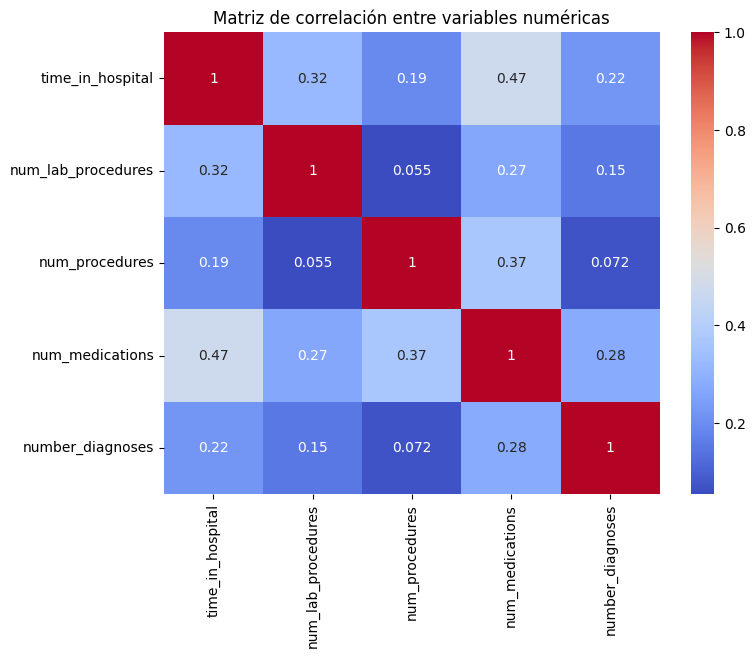

In [75]:
# Seleccionamos las variables numéricas:

numeric_vars = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']

# Calculamos matriz de correlación:

corr_matrix = df_grouped[numeric_vars].corr()

# Mostramos matriz de correlación con heatmap:

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

Podemos observar que entre las variables numéricas no existen pares con alta correlación (el máximo que hay 0,47, correlación moderada no suficientemente alta como para descartar ninguna variable)t.

### 4.2.- Numérica vs Categórica

En esta fase la idea principal es comparar cada una de las variables numéricas contra la variable objetivo y ver si tienen todas algo de relación con la probabilidad de un paciente ser readmitido a los 30 dias.

##### Boxplots

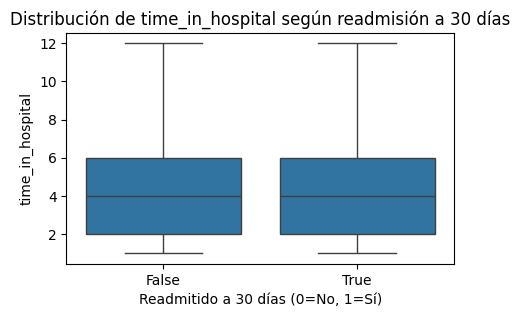

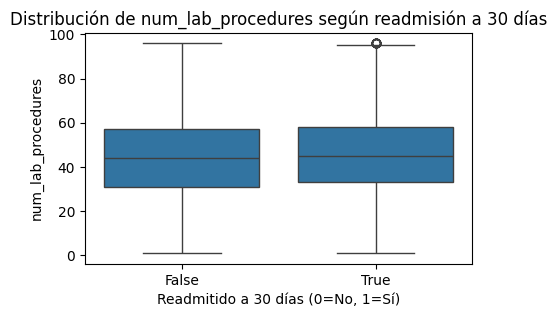

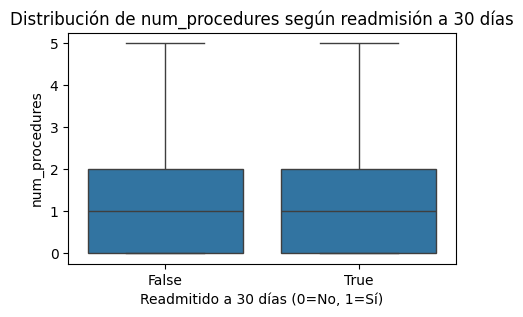

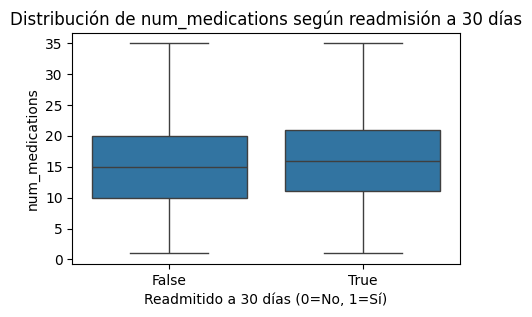

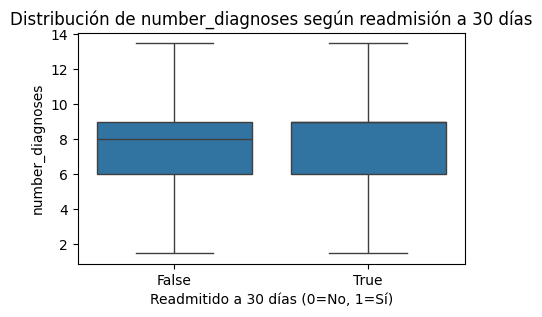

In [76]:
# Comparamos visualmente cada variable numérica con la variable objetivo readmit_30_days usando boxplots:

for col in numeric_vars:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='readmit_30_days', y=col, data=df_grouped)
    plt.title(f'Distribución de {col} según readmisión a 30 días')
    plt.xlabel('Readmitido a 30 días (0=No, 1=Sí)')
    plt.ylabel(col)
    plt.show()

Las cajas, los bigotes y la mediana nos demuestran que con la única variable numérica con la que puede tener correlación nuestra variable objetivo es con number_diagnoses. Como number_diagnoses no sigue una distribución normal, no haremos un ANOVA ni t-test sobre esta variable. En su lugar haremos el de Kruskal-Wallis y el test de Mann-Whitney.

El resto de las variables numéricas: time_in_hospital, num_lab_procedures, num_procedures y num_medications podríamos descartarlas por su escasa correlación con la variable objetivo.

##### Test de Kruskal-Wallis y Test de Mann-Whitney con number_diagnoses

In [77]:
grupos = [df[df['readmit_30_days'] == val]['number_diagnoses'] for val in df['readmit_30_days'].unique()]

stat, p = kruskal(*grupos)

print("Test de Kruskal-Wallis")
print("Estadístico H:", stat)
print("P-valor:", p)
if p < 0.05:
    print("Hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.")
else:
    print("No hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.")

Test de Kruskal-Wallis
Estadístico H: 227.00842979034525
P-valor: 2.6777644509839195e-51
Hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.


H = 227.01 es un valor muy alto, lo que indica una gran diferencia en la distribución de number_diagnoses entre los grupos de pacientes readmitidos y no readmitidos.

El p-value es 2,68e-51, prácticamente cero, lo que evidencia que la cantidad de diagnósticos (number_diagnoses) no es la misma entre los pacientes que fueron readmitidos y los que no. En otras palabras, number_diagnoses está claramente correlacionada con la readmit_30_days.

In [78]:
# Grupos según readmit_30_days:

grupo_no_readmit = df[df['readmit_30_days'] == False]['number_diagnoses']
grupo_readmit = df[df['readmit_30_days'] == True]['number_diagnoses']

stat, p = mannwhitneyu(grupo_no_readmit, grupo_readmit, alternative='two-sided')

print("Test de Mann-Whitney U")
print("Estadístico U:", stat)
print("P-valor:", p)
if p < 0.05:
    print("Hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.")
else:
    print("No hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.")

Test de Mann-Whitney U
Estadístico U: 555102381.0
P-valor: 2.6777717689371373e-51
Hay diferencia significativa entre readmitidos y no readmitidos en number_diagnoses.


El Estadístico U es muy alto y el p-valor es casi cero, muy inferior a 0.05, por lo que podemos rechazar la hipótesis nula y de nuevo verificamos que hay correlación entre las variables.

### Categórica vs Categórica

Al igual que con las numéricas, observamos el comportamiento de cada una de estas variables categóricas con respecto a la variable objetivo. Emplearemos los test de chi-cuadrado.

##### Tablas de Contingencia

In [79]:
# Seleccionamos las variables numéricas:

categoricas = ['race', 'gender', 'age', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'insulin', 'change', 'diabetesMed', 'medicare', 'had_emergency',
               'had_inpatient_days', 'had_outpatient_days']

for var in categoricas:
    print(f"Tabla normalizada (por filas) con totales para '{var}':")
    tabla = pd.crosstab(df[var], df_grouped['readmit_30_days'], normalize='index', margins=True)
    print(tabla)
    print("\n" + "-"*60 + "\n")

Tabla normalizada (por filas) con totales para 'race':
readmit_30_days     False      True
race                               
AfricanAmerican  0.887819  0.112181
Asian            0.898596  0.101404
Caucasian        0.887094  0.112906
Hispanic         0.895925  0.104075
Other            0.903654  0.096346
Unknown          0.917217  0.082783
All              0.888398  0.111602

------------------------------------------------------------

Tabla normalizada (por filas) con totales para 'gender':
readmit_30_days     False      True
gender                             
Female           0.887548  0.112452
Male             0.889385  0.110615
All              0.888398  0.111602

------------------------------------------------------------

Tabla normalizada (por filas) con totales para 'age':
readmit_30_days         False      True
age                                    
30-60_years          0.898457  0.101543
30_years_or_younger  0.888800  0.111200
Over_60_years        0.883875  0.116125
All 

Según los resultados anteriores, las variables que mayor influencia podrían tener en nuestra variable objetivo son:  had_emergency, had_inpatient_days, discharge_disposition_id, y medical_specialty, mientras que las variables insulina, diabetesMed y change muestran correlación aunque no tan marcada.

Por otro lado, race, gender, y age muestran diferencias muy pequeñas o sutiles.

##### Gráficos de Barras Apiladas

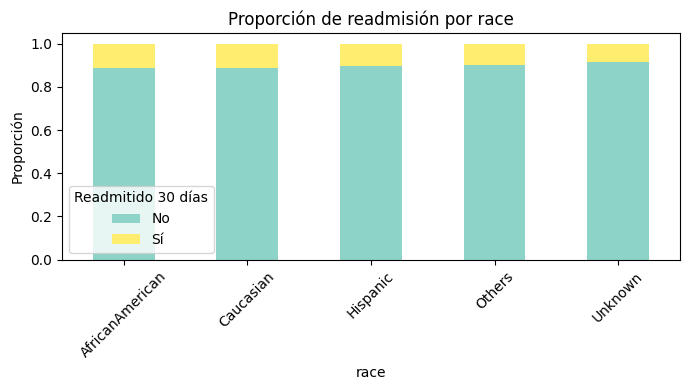

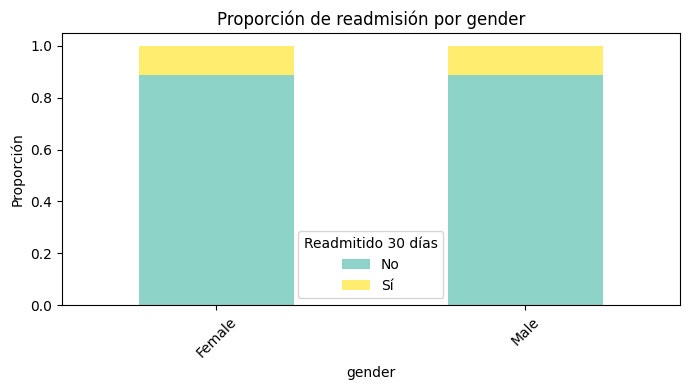

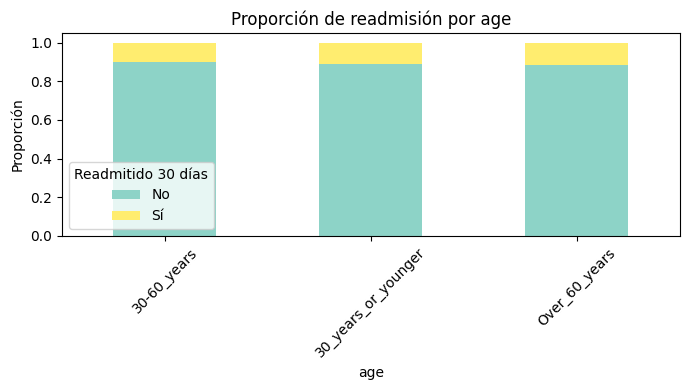

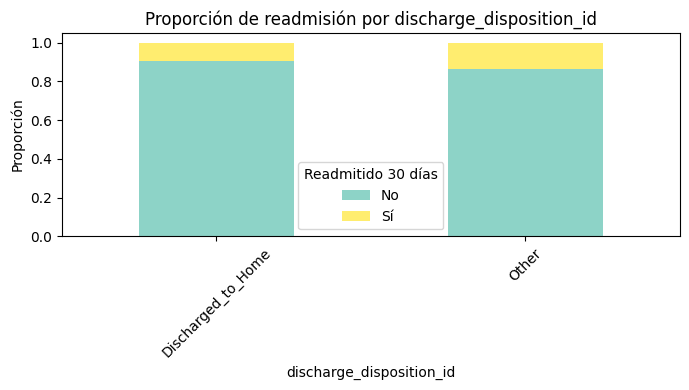

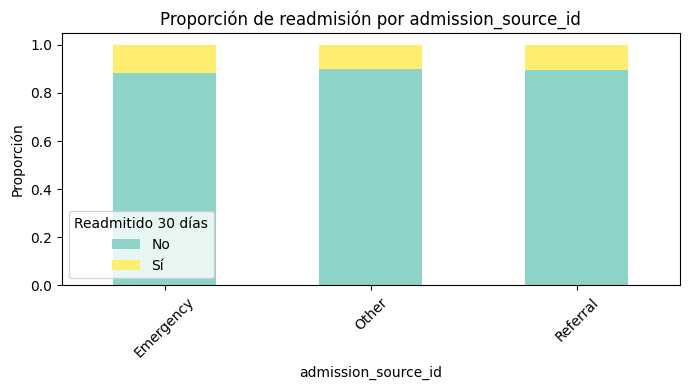

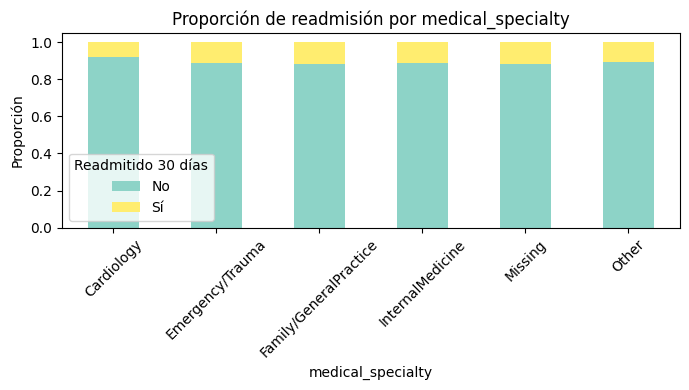

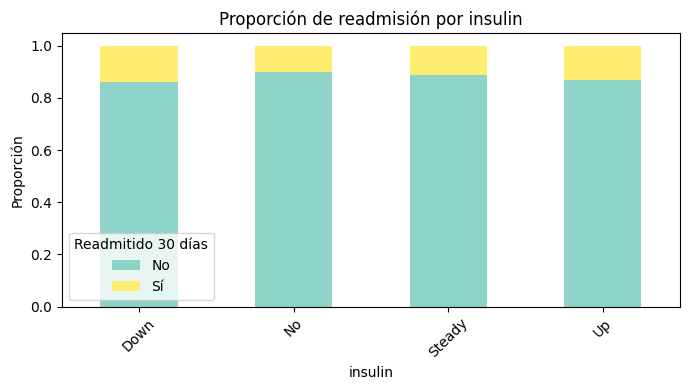

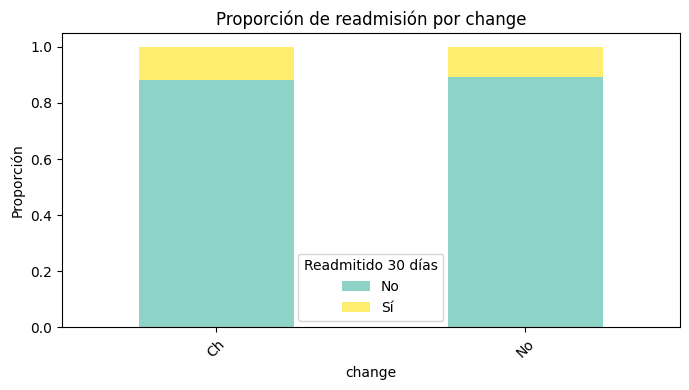

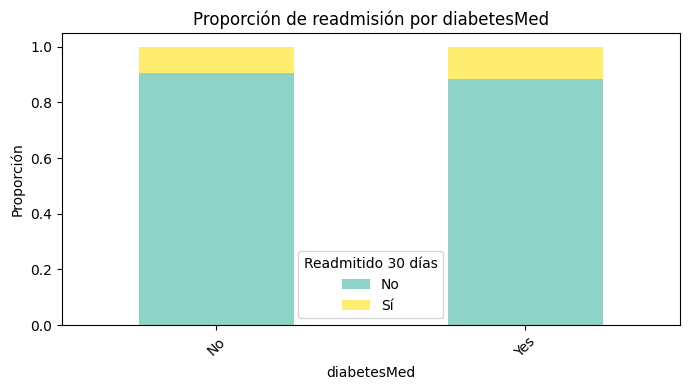

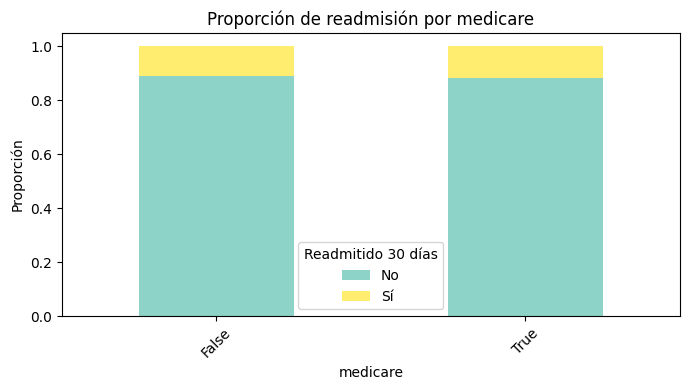

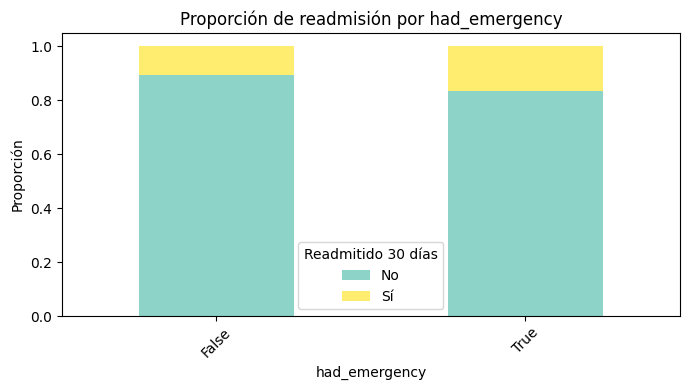

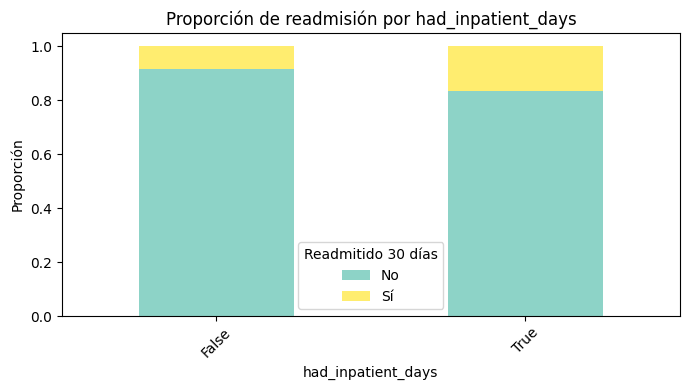

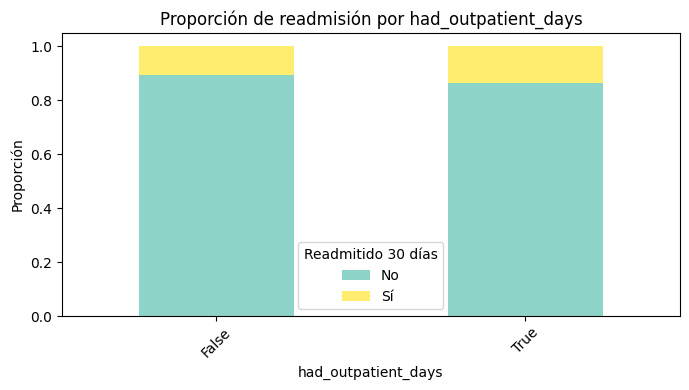

In [80]:
for var in categoricas:
    tabla = pd.crosstab(df_grouped[var], df_grouped['readmit_30_days'], normalize='index')
    ax = tabla.plot(kind='bar', stacked=True, figsize=(7, 4), colormap='Set3')
    plt.title(f'Proporción de readmisión por {var}')
    plt.xlabel(var)
    plt.ylabel('Proporción')
    plt.legend(title='Readmitido 30 días', labels=['No', 'Sí'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### Test de Chi-Cuadrado

In [81]:
for var in categoricas:
    tabla_contingencia = pd.crosstab(df_grouped[var], df_grouped['readmit_30_days'])
    chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"Variable: {var}")
    print(f"Chi-cuadrado: {chi2:.3f}")
    print(f"P-valor: {p:.3e}")
    print(f"Grados de libertad: {dof}")
    print("-" * 30)

Variable: race
Chi-cuadrado: 25.647
P-valor: 3.728e-05
Grados de libertad: 4
------------------------------
Variable: gender
Chi-cuadrado: 0.842
P-valor: 3.588e-01
Grados de libertad: 1
------------------------------
Variable: age
Chi-cuadrado: 45.494
P-valor: 1.322e-10
Grados de libertad: 2
------------------------------
Variable: discharge_disposition_id
Chi-cuadrado: 514.265
P-valor: 7.485e-114
Grados de libertad: 1
------------------------------
Variable: admission_source_id
Chi-cuadrado: 38.781
P-valor: 3.791e-09
Grados de libertad: 2
------------------------------
Variable: medical_specialty
Chi-cuadrado: 74.596
P-valor: 1.130e-14
Grados de libertad: 5
------------------------------
Variable: insulin
Chi-cuadrado: 190.782
P-valor: 4.137e-41
Grados de libertad: 3
------------------------------
Variable: change
Chi-cuadrado: 38.613
P-valor: 5.167e-10
Grados de libertad: 1
------------------------------
Variable: diabetesMed
Chi-cuadrado: 74.656
P-valor: 5.602e-18
Grados de libertad

Finalmente, según los p-valores del test de Chi-Cuadrado, únicamente podríamos considerar variable independiente de nuestra variable objetivo (con un nivel de significacncia del 0,05) a gender, eliminándola por tanto de nuestro DataFrame..